## 2. Feature Engineering — Artist Average Popularity

For each artist we compute the mean popularity of their **top 10 most popular tracks**.  
This captures hit-making ability rather than back-catalog average, so prolific artists  
with many deep cuts (e.g. Taylor Swift) are not penalised.


In [ ]:
import ast

# Extract primary artist (first name in the list)
def primary_artist(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed[0] if isinstance(parsed, list) and len(parsed) > 0 else val
    except:
        return val

df['primary_artist'] = df['artists'].apply(primary_artist)

# Artist avg popularity = mean of top 10 most popular tracks per artist
# Using top 10 (not all tracks) so prolific artists with large back catalogs
# are not penalised — this captures hit-making ability
top10_mean = (
    df[df['popularity'] > 0]
    .groupby('primary_artist')['popularity']
    .apply(lambda x: x.nlargest(10).mean())
    .rename('artist_avg_popularity')
)
df = df.join(top10_mean, on='primary_artist')
df['artist_avg_popularity'] = df['artist_avg_popularity'].fillna(df['popularity'].median())

r = df['artist_avg_popularity'].corr(df['popularity'])
print(f'Correlation — artist_avg_popularity vs popularity: {r:.4f}')

# Spot check
for artist in ['Taylor Swift', 'Drake', 'Billie Eilish', 'Ed Sheeran']:
    val = top10_mean.get(artist)
    if val:
        print(f'  {artist}: {val:.1f}')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## 1. Load Data

In [2]:
path = '/Users/caglaakin/Desktop/Imperial Data Science Program/Capstone Project/Spotify 2 Vikesh/spotify_data 2.csv'
df = pd.read_csv(path)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (169909, 19)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928


## 2. Parse Artists Column

The `artists` column contains Python-list strings like `['Coldplay']` or `['Jay-Z', 'Alicia Keys']`.  
We extract the **primary artist** (first listed) as a clean string.

## 4. Exploratory Analysis — Artist Popularity vs Track Popularity

In [7]:
corr = df['artist_avg_popularity'].corr(df['popularity'])
print(f"Pearson correlation — artist_avg_popularity vs popularity: {corr:.4f}")

Pearson correlation — artist_avg_popularity vs popularity: 0.8638


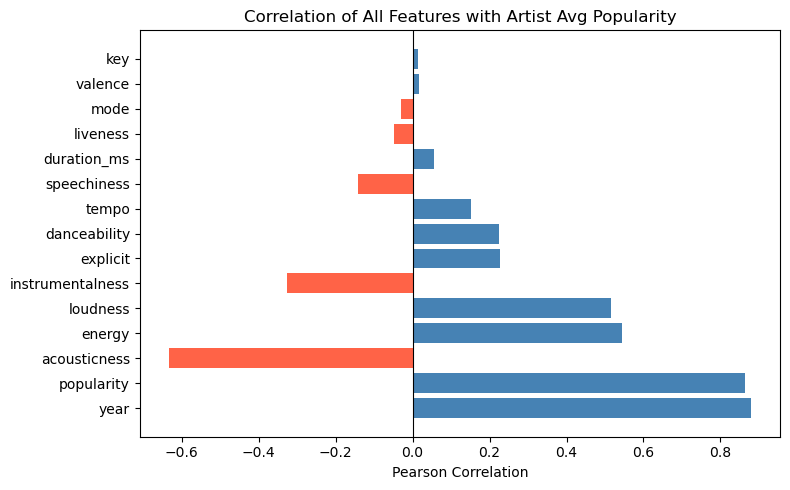

year                0.8792
popularity          0.8638
acousticness       -0.6336
energy              0.5445
loudness            0.5145
instrumentalness   -0.3275
explicit            0.2279
danceability        0.2252
tempo               0.1506
speechiness        -0.1428
duration_ms         0.0557
liveness           -0.0485
mode               -0.0301
valence             0.0154
key                 0.0135
dtype: float64

In [9]:
# Correlation of artist_avg_popularity vs all other numeric features
numeric_df = df.select_dtypes(include='number').drop(columns=['artist_avg_popularity'])
corr_with_artist = numeric_df.corrwith(df['artist_avg_popularity']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in corr_with_artist]
plt.barh(corr_with_artist.index, corr_with_artist.values, color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Pearson Correlation')
plt.title('Correlation of All Features with Artist Avg Popularity')
plt.tight_layout()
plt.show()

corr_with_artist.round(4)

## 5. Model Comparison — With vs Without Artist Popularity Feature

We run two models side-by-side to isolate how much `artist_avg_popularity` improves predictions.

In [1]:
X_with    = df_model.drop(columns=['popularity'])
X_without = X_with.drop(columns=['artist_avg_popularity'])
y         = df_model['popularity']

# Same split for fair comparison
X_tr_w,  X_te_w,  y_train, y_test = train_test_split(X_with,    y, test_size=0.2, random_state=42)
X_tr_wo, X_te_wo, _,       _      = train_test_split(X_without, y, test_size=0.2, random_state=42)

print(f"Features WITH artist popularity:    {X_tr_w.shape[1]}")
print(f"Features WITHOUT artist popularity: {X_tr_wo.shape[1]}")

NameError: name 'df_model' is not defined

In [13]:
def fit_and_evaluate(X_train, X_test, y_train, y_test, label):
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(X_train)
    Xte_s = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr_s, y_train)

    y_tr_pred = model.predict(Xtr_s)
    y_te_pred = model.predict(Xte_s)

    results = {
        'model':      model,
        'scaler':     scaler,
        'features':   X_train.columns.tolist(),
        'r2_train':   r2_score(y_train, y_tr_pred),
        'r2_test':    r2_score(y_test,  y_te_pred),
        'rmse_train': np.sqrt(mean_squared_error(y_train, y_tr_pred)),
        'rmse_test':  np.sqrt(mean_squared_error(y_test,  y_te_pred)),
        'y_te_pred':  y_te_pred
    }
    print(f"[{label}]  Train R²: {results['r2_train']:.4f}  RMSE: {results['rmse_train']:.4f} "
          f"| Test R²: {results['r2_test']:.4f}  RMSE: {results['rmse_test']:.4f}")
    return results

res_with    = fit_and_evaluate(X_tr_w,  X_te_w,  y_train, y_test, 'WITH artist feature   ')
res_without = fit_and_evaluate(X_tr_wo, X_te_wo, y_train, y_test, 'WITHOUT artist feature')

[WITH artist feature   ]  Train R²: 0.8137  RMSE: 9.3134 | Test R²: 0.8109  RMSE: 9.3964
[WITHOUT artist feature]  Train R²: 0.7843  RMSE: 10.0199 | Test R²: 0.7820  RMSE: 10.0891


In [14]:
comparison = pd.DataFrame({
    'Model':      ['Without artist_avg_popularity', 'Without artist_avg_popularity',
                   'With artist_avg_popularity',    'With artist_avg_popularity'],
    'Split':      ['Train', 'Test', 'Train', 'Test'],
    'R²':         [res_without['r2_train'], res_without['r2_test'],
                   res_with['r2_train'],    res_with['r2_test']],
    'RMSE':       [res_without['rmse_train'], res_without['rmse_test'],
                   res_with['rmse_train'],    res_with['rmse_test']]
}).round(4)

comparison

,Model,Split,R²,RMSE
0,Without artist_avg_popularity,Train,0.7843,10.0199
1,Without artist_avg_popularity,Test,0.7820,10.0891
2,With artist_avg_popularity,Train,0.8137,9.3134
3,With artist_avg_popularity,Test,0.8109,9.3964


In [15]:
r2_gain   = res_with['r2_test'] - res_without['r2_test']
rmse_gain = res_without['rmse_test'] - res_with['rmse_test']
print(f"Adding artist_avg_popularity:")
print(f"  R² improvement (test):   +{r2_gain:.4f}  ({r2_gain*100:.2f} percentage points)")
print(f"  RMSE reduction (test):   -{rmse_gain:.4f}")

Adding artist_avg_popularity:
  R² improvement (test):   +0.0289  (2.89 percentage points)
  RMSE reduction (test):   -0.6928


## 6. Actual vs Predicted — With Artist Feature

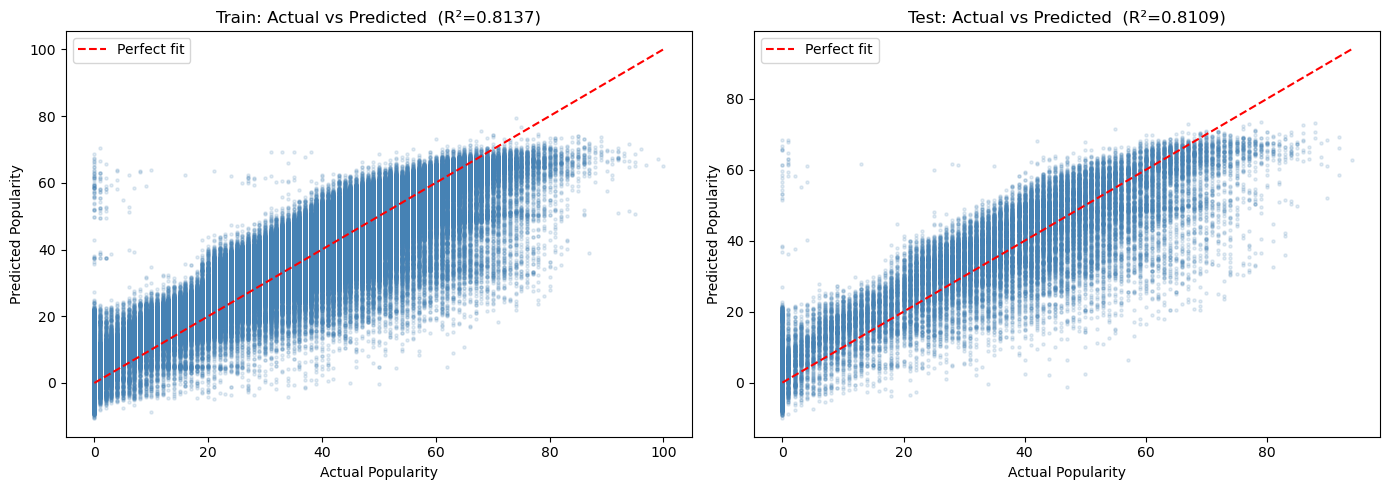

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train,
     res_with['model'].predict(res_with['scaler'].transform(X_tr_w)), 'Train'),
    (axes[1], y_test,  res_with['y_te_pred'], 'Test'),
]:
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, color='steelblue')
    mn, mx = int(y_true.min()), int(y_true.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Popularity')
    ax.set_ylabel('Predicted Popularity')
    ax.set_title(f'{title}: Actual vs Predicted  (R²={r2:.4f})')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Feature Coefficients — Where Does Artist Popularity Rank?

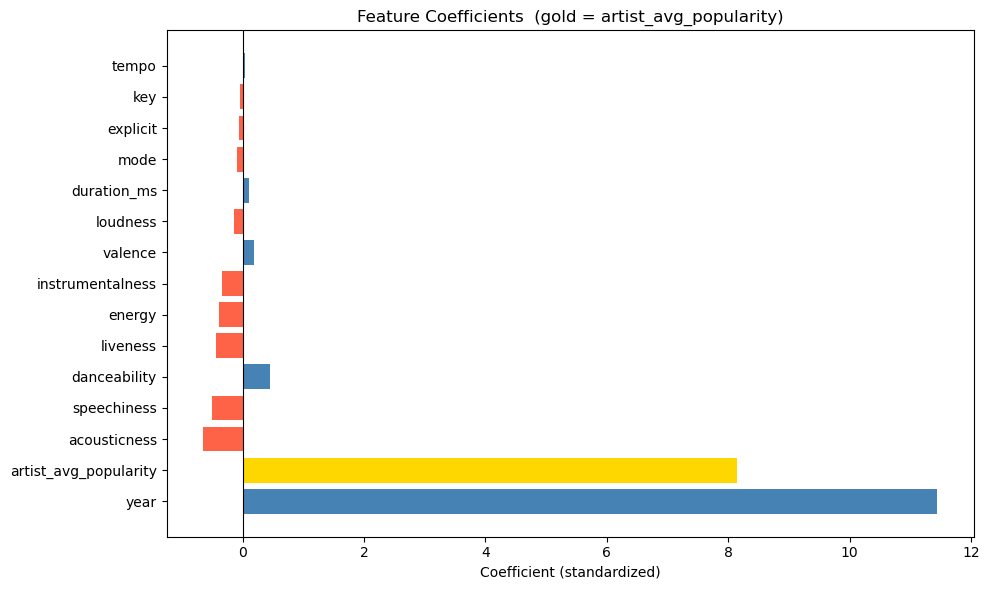

,Feature,Coefficient
0,year,11.446669
1,artist_avg_popularity,8.152446
2,acousticness,-0.647788
3,speechiness,-0.504626
4,danceability,0.456715
5,liveness,-0.438931
6,energy,-0.399092
7,instrumentalness,-0.348061
8,valence,0.182317
9,loudness,-0.146515


In [17]:
coef_df = pd.DataFrame({
    'Feature':     res_with['features'],
    'Coefficient': res_with['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

# Highlight artist feature
colors = ['gold' if f == 'artist_avg_popularity' else
          ('steelblue' if c > 0 else 'tomato')
          for f, c in zip(coef_df['Feature'], coef_df['Coefficient'])]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient (standardized)')
plt.title('Feature Coefficients  (gold = artist_avg_popularity)')
plt.tight_layout()
plt.show()

coef_df